In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
from scipy.stats import mannwhitneyu
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftis = pd.read_csv(f'{path}/../tissue40.list', sep='\t')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/sheepGTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [4]:
color_dict = {
    'eQTL': '#FC3726',
    'eeQTL': '#FFC300',
    'isoQTL': '#FF8D1A',
    'enQTL': '#CD853F',
    'sQTL': '#55A868',
    'stQTL': '#3A5FCD',
    "3aQTL": '#984EA3'}

# Fig. 4a

In [3]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/combine_results"
df = pd.DataFrame()
prefix = ['e', 'ee', 'iso', 'en', 's', 'st', '3a']
for i, p in enumerate(prefix):
    # input data
    if p == '3a':
        df_ = pd.read_csv(f'{path}/sheep_{p}qtl_summary.txt', sep='\t', usecols=['Tissue', "Number of 3a'Genes", '1', '2', '3', 'geq4'])
        df_['QTL'] = f'{p}QTL'
        df_['geq1'] = df_['2'] + df_['3'] + df_['geq4']
        df_['geq1_perc'] = df_['geq1'] / df_["Number of 3a'Genes"] * 100
    else:
        df_ = pd.read_csv(f'{path}/sheep_{p}qtl_summary.txt', sep='\t', usecols=['Tissue', f'Number of {p}Genes', '1', '2', '3', 'geq4'])
        df_['QTL'] = f'{p}QTL'
        df_['geq1'] = df_['2'] + df_['3'] + df_['geq4']
        df_['geq1_perc'] = df_['geq1'] / df_[f'Number of {p}Genes'] * 100
        
    df_ = df_[['QTL', 'Tissue', 'geq1', 'geq1_perc']]
    df = pd.concat([df, df_])
df

,QTL,Tissue,geq1,geq1_perc
0,eQTL,Oviduct,0,0.000000
1,eQTL,Rectum,0,0.000000
2,eQTL,Trachea,0,0.000000
3,eQTL,Hippocampus,0,0.000000
4,eQTL,Embryo,0,0.000000
...,...,...,...,...
45,3aQTL,Longissimus_muscle,148,13.120567
46,3aQTL,Brain,127,12.402344
47,3aQTL,Adipose,160,14.171833
48,3aQTL,Liver,246,17.982456


In [6]:
df.groupby('QTL')[['geq1', 'geq1_perc']].mean()

,geq1,geq1_perc
QTL,,
3aQTL,47.540000,5.930428
eQTL,670.235294,11.319993
eeQTL,416.000000,13.535785
enQTL,70.960784,10.400868
isoQTL,478.039216,16.651053
sQTL,294.450980,15.076193
stQTL,263.980392,8.083481


In [7]:
def load_summary(p):
    path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/combine_results"
    summary_df_indep = pd.read_csv(f'{path}/sheep_{p}qtl_summary.txt', sep='\t', 
                                   usecols=['Tissue', 'Sample size', '1', '2', '3', 'geq4', 'Color']).rename(columns={'geq4':'≥ 4'})
    summary_df_indep['Type'] = '# independent QTLs'
    # input credible set summary
    #summary_df_cs = pd.read_csv(f'{path}/sheep_{p}qtl_cs_summary.txt', sep='\t', usecols=['Tissue', '1', '2', '3', '≥ 4'])
    #summary_df_cs = pd.merge(summary_df_cs, summary_df_indep[['Tissue', 'Sample size', 'Color']], on='Tissue')
    #summary_df_cs['Type'] = '# 95% credible sets'
    ## merge
    #summary_df = pd.concat([summary_df_indep, summary_df_cs]).fillna(0)
    summary_df = summary_df_indep
    summary_df = summary_df.sort_values(by='Sample size', ascending=False)
    summary_df['Tissue'] = summary_df['Tissue'].str.replace('_', ' ')
    #summary_df_melt = summary_df.melt(id_vars=['Tissue', 'Sample size', 'Color', 'Type'], var_name='Number', value_name='Value')
    #summary_df_melt[['Tissue','Type','Number','Value']].to_csv(f'{path}/sheep_eqtl_groupstackbar.csv', index=False)
    summary_df.set_index('Tissue', inplace=True)
    return summary_df

def format_xticks(value, pos):
    if value >= 1000:
        return f'{value/1000:.0f}k'
    else:
        return f'{value:.0f}'

def plot_summary(summary_df, p):
    path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/combine_results"
    sns.set_theme(style="ticks")
    #fig, ax = plt.subplots()
    figsize= (3, 8)
    c = summary_df[['1','2','3','≥ 4']].columns[::-1]
    
    df_plot1 = (summary_df.loc[summary_df['Type']=='# independent QTLs', c])
    #df_plot2= (summary_df.loc[summary_df['Type']=='# 95% credible sets', c])
    df_plot1.plot(kind='barh', stacked=True, linewidth=0, width=0.8,
                  color=sns.color_palette("Blues_r", 4), figsize=figsize)
    
    #df_plot2.plot(kind='barh', ax=ax, stacked=True, linewidth=0, width=0.4, position=1,
    #              color=sns.color_palette("flare_r", 4), figsize=figsize)
    ax.set_xlabel('Number of eGenes or molecular phenotypes')
    ax.set_ylabel('')
    ax.set_title(f'{p}QTL')
    ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
    sns.despine()
    #plt.savefig(f'{path}/{p}QTL.summary.susier_independent.pdf', dpi='figure', format='pdf', bbox_inches='tight')
    

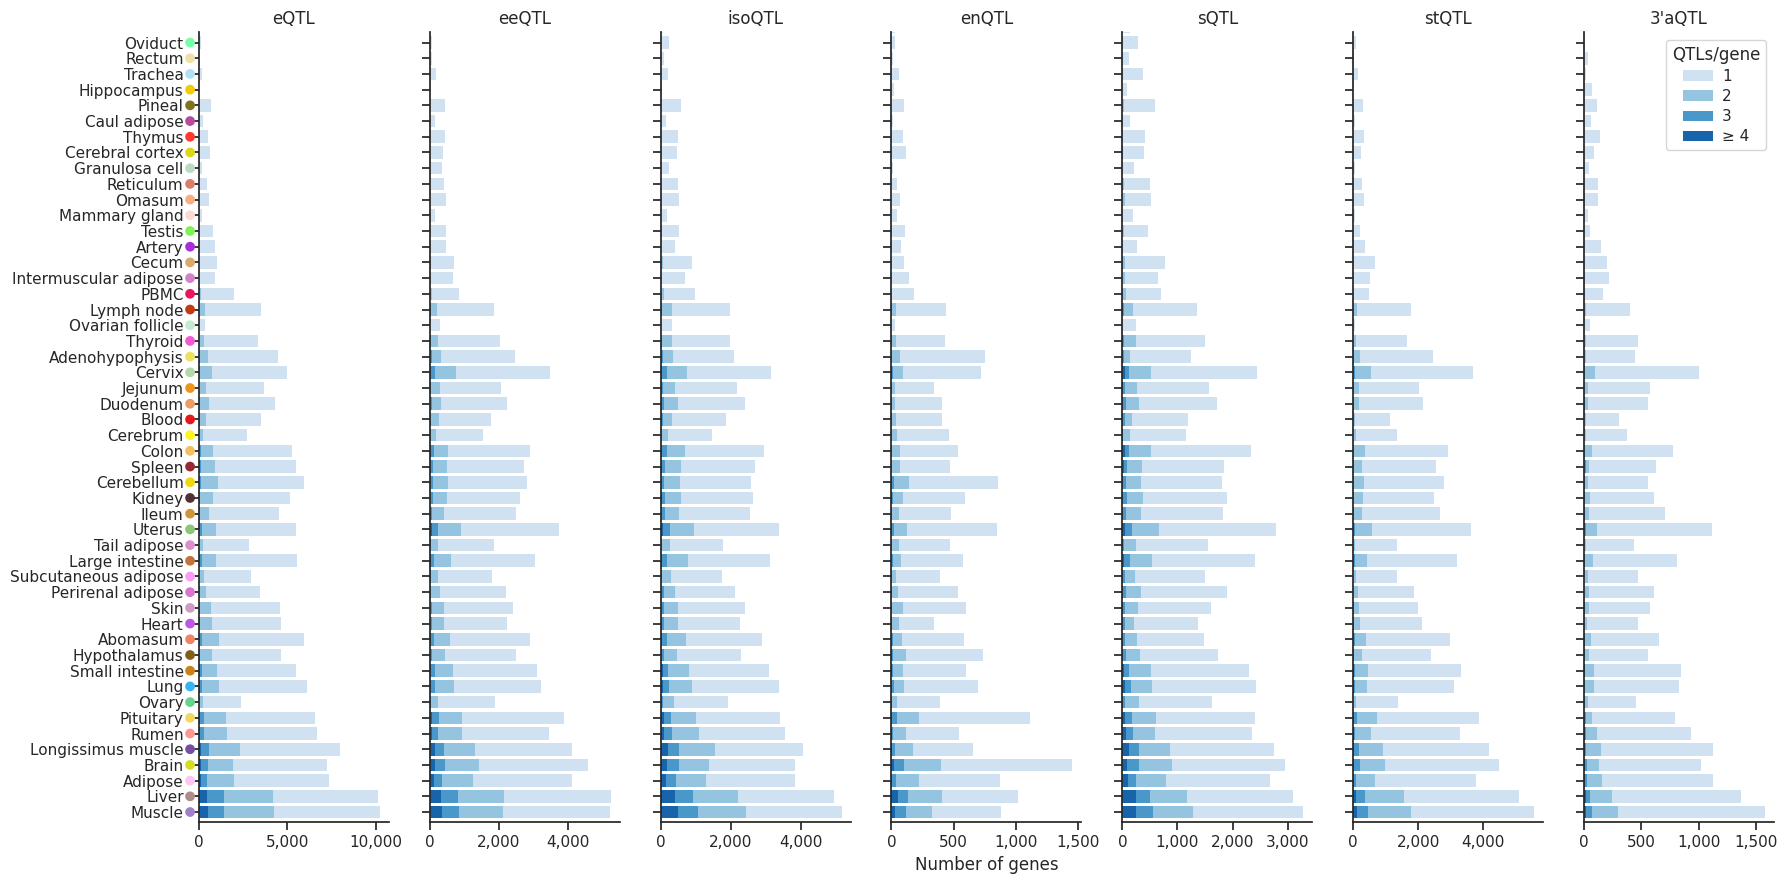

In [8]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/combine_results"
sns.set_theme(style="ticks")
fig, axes = plt.subplots(nrows=1, ncols=7, sharex=False, sharey=True)
figsize=(18, 9)
c = ['≥ 4', '3', '2', '1']

prefix = ['e', 'ee', 'iso', 'en', 's', 'st', '3a']
width = 0.8
for i, p in enumerate(prefix):
    plt.subplot(1, 7, i+1)
    # input data
    summary_df = pd.read_csv(f'{path}/sheep_{p}qtl_summary.txt', sep='\t', usecols=['Tissue', 'Sample size', '1', '2', '3', 'geq4', 'Color']).rename(columns={'geq4':'≥ 4'})      
    summary_df = summary_df.sort_values(by='Sample size', ascending=False)
    summary_df['Tissue'] = summary_df['Tissue'].str.replace('_', ' ')
    summary_df.set_index('Tissue', inplace=True)
    
    # plot
    ax=axes[i]
    if p=='3a':
        summary_df[c].plot(kind='barh', stacked=True, linewidth=0, width=width, ax=ax, legend=True,
                    color=sns.color_palette("Blues_r", 4), figsize=figsize)
        plt.title("3'aQTL")
        h,_ = ax.get_legend_handles_labels()
        labels = ['1', '2', '3', '≥ 4']
        ax.legend(h[::-1], labels, loc='upper right', title=f'QTLs/gene',
                 labelspacing=0.33, handletextpad=0.6)
    else:
        summary_df[c].plot(kind='barh', stacked=True, linewidth=0, width=width, ax=ax, legend=False,
                    color=sns.color_palette("Blues_r", 4), figsize=figsize)
        plt.title(f"{p}QTL")
    ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    plt.ylabel('')
    plt.xlabel('')
    if i==3:
        plt.xlabel('Number of genes')

ax = axes[0]
l = -500  # 左侧偏移量
ax.tick_params(axis='x', which='major')
ax.set_xlim([0, ax.get_xlim()[1]])
ax.scatter(l*np.ones(summary_df.shape[0]), np.arange(summary_df.shape[0]), c=summary_df['Color'], clip_on=False)
ax.tick_params(axis='y', pad=5)

plt.tight_layout()
sns.despine()

plt.savefig('pdf/independent_summary.pdf', dpi='figure', format='pdf', bbox_inches='tight')

# Fig. 4b

In [22]:
#input eQTL
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
causalnum = pd.read_csv(f"{path}/susier.causalnum.txt", sep="\s+", header=None,
                          names=['Credible set size', 'tissue', 'pheno_id', 'cs'])
causalnum['type'] = "eQTL"
causalsum = causalnum.groupby('Credible set size').count().reset_index().rename(columns={'pheno_id':'Number of credible sets'})
causalsum['type'] = "eQTL"
# input other QTLs
for i,qtl in enumerate(['sQTL','eeQTL', 'isoQTL', 'stQTL', '3aQTL', 'enQTL']):
    causalnum_tmp = pd.read_csv(f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/0{i+2}.{qtl}/susier.causalnum.txt", sep="\s+", header=None,
                                names=['Credible set size', 'tissue', 'pheno_id', 'cs'])
    causalnum_tmp['type'] = qtl
    #causalnum = pd.concat([causalnum, causalnum_tmp])
    causalsum_tmp = causalnum_tmp.groupby('Credible set size').count().reset_index().rename(columns={'pheno_id':'Number of credible sets'})
    causalsum_tmp['type'] = qtl
    causalsum = pd.concat([causalsum, causalsum_tmp])
causalsum

,Credible set size,tissue,Number of credible sets,cs,type
0,1,12616,12616,12616,eQTL
1,2,8170,8170,8170,eQTL
2,3,6438,6438,6438,eQTL
3,4,5409,5409,5409,eQTL
4,5,4747,4747,4747,eQTL
...,...,...,...,...,...
246,408,1,1,1,enQTL
247,426,2,2,2,enQTL
248,444,1,1,1,enQTL
249,491,1,1,1,enQTL


In [23]:
causalsum.groupby('type').apply(lambda g: g.loc[g['Credible set size'] == 1, 'Number of credible sets'].sum() / g['Number of credible sets'].sum()).reset_index(name='Proportion')

/tmp/ipykernel_16287/15465846.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  causalsum.groupby('type').apply(lambda g: g.loc[g['Credible set size'] == 1, 'Number of credible sets'].sum() / g['Number of credible sets'].sum()).reset_index(name='Proportion')


,type,Proportion
0,3aQTL,0.100244
1,eQTL,0.113982
2,eeQTL,0.105367
3,enQTL,0.084060
4,isoQTL,0.101030
5,sQTL,0.111771
6,stQTL,0.076189


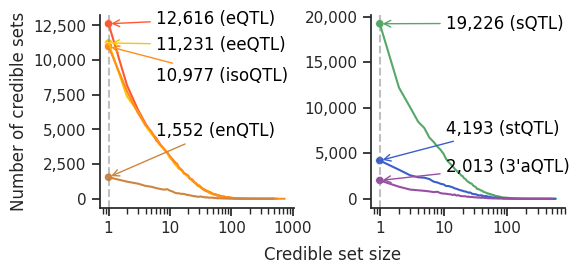

In [24]:
sns.set_theme(style="ticks")
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(6, 2.5))

qtl1 = ['eQTL', 'eeQTL', 'isoQTL', 'enQTL']
qtl2 = ['sQTL', 'stQTL', '3aQTL']

plt.subplot(121)
plt.axvline(x=1, color='grey', alpha=.5, linestyle='--')
dfplot = causalsum[causalsum['type'].isin(qtl1)]
dfplot1 = dfplot[dfplot["Credible set size"]==1]
ax = sns.lineplot(data=dfplot, x="Credible set size", y="Number of credible sets", hue="type",
                  hue_order= qtl1, palette=color_dict, legend=False)
ax = sns.scatterplot(data=dfplot1, x="Credible set size", y="Number of credible sets",
                     hue="type", hue_order=qtl1, palette=color_dict, legend=False)
#ax.set_xlim(0, ax.get_xlim()[1])
ax.set_xscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_label_coords(1.2, -0.2)  # (x, y) 坐标
plt.ylabel('Number of credible sets')
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# annotation
for i, row in dfplot1.iterrows():
    x = 1
    y = row['Number of credible sets']
    qtl = row['type']
    if qtl == 'eQTL':
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 5, y),
                    arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')
    elif qtl == 'isoQTL':
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 5, y - 2500),
                    arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')
    elif qtl == 'enQTL':
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 5, y + 3000),
                    arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')
    else:
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 5, y - 500),
                    arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')


plt.subplot(122)
plt.axvline(x=1, color='grey', alpha=.5, linestyle='--')
dfplot = causalsum[causalsum['type'].isin(qtl2)]
dfplot1 = dfplot[dfplot["Credible set size"]==1]
ax = sns.lineplot(data=dfplot, x="Credible set size", y="Number of credible sets", hue="type",
                  hue_order=qtl2, palette=color_dict, legend=False)
ax = sns.scatterplot(data=dfplot1, x="Credible set size", y="Number of credible sets",
                     hue="type", hue_order=qtl2, palette=color_dict, legend=False)
#ax.set_xlim(0, ax.get_xlim()[1])
ax.set_xscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.ylabel('')
plt.xlabel('')

# annotation
for i, row in dfplot1.iterrows():
    x = 1
    y = row['Number of credible sets']
    qtl = row['type']
    if qtl == 'sQTL':
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 10, y - 500),
                    arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')
    elif qtl == 'stQTL':
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 10, y + 3000),
                arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')
    elif qtl == '3aQTL':
        ax.annotate(text=f"{y:,} (3'aQTL)", xy=(x, y), xytext=(x + 10, y + 1000),
                arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')
    else:
        ax.annotate(text=f'{y:,} ({qtl})', xy=(x, y), xytext=(x + 10, y + 1000),
                arrowprops=dict(arrowstyle='->', color=color_dict[qtl]), color='black')

fig.subplots_adjust(wspace=0.4)
plt.savefig('pdf/finemapped_molQTLs_credible_sets.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

# Fig. 4c-f

In [5]:
perm = dict()
indep = dict()
signal = dict()
qtls = ['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL']

#input eQTL
perm['eQTL'] = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split/tensorqtl_permutation.txt',sep ='\t')
indep['eQTL'] = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split/tensorqtl_independent_qtl.txt.gz',sep ='\t')
signal['eQTL'] = indep['eQTL'].groupby(['tissue','phenotype_id'])['rank'].max().reset_index().rename(columns={'rank':'num'})
signal['eQTL'].loc[signal['eQTL']['num']>=4, 'num'] = 4
indep['eQTL'] = pd.merge(indep['eQTL'], signal['eQTL'], on=["tissue", "phenotype_id"])
indep['eQTL']['signal'] = indep['eQTL']['rank']
indep['eQTL'].loc[indep['eQTL']['signal']>=4, 'signal'] = 4

# input other QTLs
for i,qtl in enumerate(['sQTL', 'eeQTL', 'isoQTL', 'stQTL', '3aQTL', 'enQTL']):
    perm[qtl] = pd.read_csv(f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/0{i+2}.{qtl}/tensorqtl_permutation.txt",sep ='\t')
    indep[qtl] = pd.read_csv(f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/0{i+2}.{qtl}/tensorqtl_independent_qtl.txt.gz",sep ='\t')
    if qtl!="stQTL":
        perm[qtl] = perm[qtl].drop(columns=['phenotype_id']).rename(columns={'group_id': 'phenotype_id'})
        indep[qtl] = indep[qtl].drop(columns=['phenotype_id']).rename(columns={'group_id': 'phenotype_id'})
    signal[qtl] = indep[qtl].groupby(['tissue','phenotype_id'])['rank'].max().reset_index().rename(columns={'rank':'num'})
    signal[qtl].loc[signal[qtl]['num']>=4, 'num'] = 4
    indep[qtl] = pd.merge(indep[qtl], signal[qtl], on=["tissue", "phenotype_id"])
    indep[qtl]['signal'] = indep[qtl]['rank']
    indep[qtl].loc[indep[qtl]['signal']>=4, 'signal'] = 4

## median TPM

In [170]:
#df_tpm = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/sheep.PCGlnc.gene.merged.tpm.txt',sep ='\t', index_col=0)
#df_tpm_median = pd.DataFrame()
#for tis in tislist:
#    ind = [line.strip() for line in open(f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split/{tis}/{tis}.samplelist", 'r')]
#    df_ = df_tpm[ind]
#    df_median_ = df_.iloc[:, 1:].median(axis=1).to_frame(name="median TPM").reset_index()
#    df_median_['tissue'] = tis
#    df_tpm_median = pd.concat([df_tpm_median, df_median_])
#df_tpm_median.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/sheep.PCGlnc.gene.merged.median_tpm.tissue.txt',sep='\t', index=False)

In [10]:
df_tpm_median = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/sheep.PCGlnc.gene.merged.median_tpm.tissue.txt', sep ='\t')
df_tpm_median['log2(TPM)'] = np.log2(df_tpm_median['median TPM'])
df_tpm_median['log2(TPM+0.1)'] = np.log2(df_tpm_median['median TPM']+0.1)
df_tpm_median

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Geneid,median TPM,tissue,log2(TPM),log2(TPM+0.1)
0,LOC114112203,0.000000,Muscle,-inf,-3.321928
1,LOC114110836,0.000000,Muscle,-inf,-3.321928
2,LOC114113923,1.770675,Muscle,0.824299,0.903559
3,LOC114112459,0.128124,Muscle,-2.964387,-2.132110
4,FAM240C,0.062073,Muscle,-4.009898,-2.625287
...,...,...,...,...,...
1310644,KEF53_p05,2968.050000,Oviduct,11.535300,11.535348
1310645,KEF53_p04,3149.780000,Oviduct,11.621035,11.621081
1310646,KEF53_p03,2.918940,Oviduct,1.545445,1.594042
1310647,KEF53_p02,1.385320,Oviduct,0.470219,0.570774


In [11]:
tpm = dict()
for qtl in qtls:
    tpm[qtl] = pd.merge(perm[qtl], df_tpm_median, left_on=["tissue", "phenotype_id"], right_on=["tissue", "Geneid"])
    tpm[qtl] = pd.merge(df_tpm_median, signal[qtl], left_on=["tissue", "Geneid"], right_on=["tissue", "phenotype_id"], how='left')
    tpm[qtl]['num'] = tpm[qtl]['num'].fillna(0)

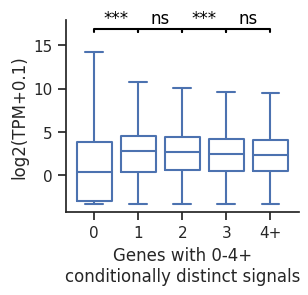

In [15]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

dfplot = tpm['eQTL']
x='num'
y='log2(TPM+0.1)'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel('Genes with 0-4+\nconditionally distinct signals')
plt.xticks([0,1,2,3,4], [0,1,2,3,'4+'])

#y_max = max(dfplot[y]) * 1.1
y_max = ax.get_ylim()[1] * 1.1
pairs=[(0,1), (1, 2), (2, 3), (3, 4)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0],y], dfplot.loc[dfplot[x]==pair[1],y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
sns.despine()

plt.savefig('pdf/Genes_with_0-4_log.pdf', dpi='figure', format='pdf', bbox_inches='tight')

## Heritability

In [17]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
df_h2 = pd.read_csv(f'{path}/omiga_h2.single.txt', sep='\t').rename(columns={'h2_g1':'Cis-heritability'})
df_h2 = df_h2.sort_values(by='Sample_size', ascending=False)
df_h2 = df_h2.dropna(subset=['Cis-heritability'])
df_h2['Cis-heritability'] = df_h2['Cis-heritability'].astype(float)
df_h2 = df_h2[df_h2['model']=='Ac'] # cis-heritability
df_h2

,Tissue,Sample_size,pheno_id,chrom,glo_snps,trans_snps,cis_snps,algo,model,vg1,ve,Cis-heritability,h2se_g1,converged
0,Muscle,713,LOC114113923,chr1,3316907,0,4019,em_aireml,Ac,2.439230e-01,0.442156,0.355532,0.005478,True
1,Muscle,713,LOC114112459,chr1,3316907,0,4019,em_aireml,Ac,5.875010e-02,0.585965,0.091126,0.001842,True
5781,Muscle,713,KANK3,chr5,3316907,0,5082,em_aireml,Ac,5.153660e-02,0.116926,0.305923,0.003737,True
5795,Muscle,713,LOC101106844,chr5,3316907,0,4446,em_aireml,Ac,9.967160e-03,0.418019,0.023289,0.000515,True
5794,Muscle,713,LOC101106588,chr5,3316907,0,4529,em_aireml,Ac,3.627730e-03,0.131758,0.026795,0.000659,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1907412,Oviduct,40,C1H1orf50,chr1,2811609,0,4675,em_aireml,Ac,1.433010e-01,0.333896,0.300298,0.308174,True
1907411,Oviduct,40,P3H1,chr1,2811609,0,4674,em_aireml,Ac,8.693490e-07,0.120477,0.000007,0.266443,True
1907410,Oviduct,40,YBX1,chr1,2811609,0,4308,em_aireml,Ac,9.291750e-02,0.042176,0.687802,0.093993,True
1907409,Oviduct,40,PPIH,chr1,2811609,0,4276,em_aireml,Ac,5.940720e-02,0.043384,0.577938,0.177574,True


In [18]:
h2 = dict()
for qtl in qtls:
    h2[qtl] = pd.merge(df_h2, signal[qtl], how='left', left_on=["Tissue","pheno_id"], right_on=["tissue","phenotype_id"])
    h2[qtl]['num'] = h2[qtl]['num'].fillna(0)

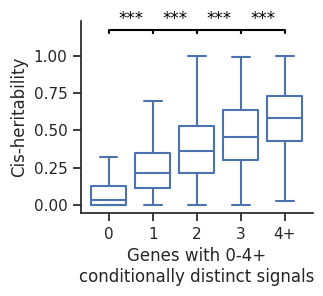

In [19]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

dfplot = h2['eQTL']
x='num'
y='Cis-heritability'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel('Genes with 0-4+\nconditionally distinct signals')
plt.xticks([0,1,2,3,4], [0,1,2,3,'4+'])

y_max = ax.get_ylim()[1] * 1.1
pairs=[(0,1), (1, 2), (2, 3), (3, 4)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0],y], dfplot.loc[dfplot[x]==pair[1],y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Genes_with_0-4_her.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

## kME

In [25]:
df_kme = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/01.MP1/02.stat/04.MP1/gene/featureCount/WGCNA/WGCNA_new/WGCNA/kME.txt', sep="\t")
df_kme

,GeneID,module,kME_value,|kME|,Tissue
0,A1BG,kME_ME0,0.179256,0.179256,Muscle
1,A4GALT,kME_ME0,0.101641,0.101641,Muscle
2,AAAS,kME_ME0,-0.065793,0.065793,Muscle
3,AACS,kME_ME0,0.039329,0.039329,Muscle
4,AADACL3,kME_ME0,0.028560,0.028560,Muscle
...,...,...,...,...,...
973226,ZYG11A,kME_ME0,-0.008649,0.008649,Oviduct
973227,ZYG11B,kME_ME1,0.431743,0.431743,Oviduct
973228,ZYX,kME_ME9,0.820933,0.820933,Oviduct
973229,ZZEF1,kME_ME12,0.417622,0.417622,Oviduct


In [26]:
kme = dict()
for qtl in qtls:
    kme[qtl] = pd.merge(perm[qtl], df_kme, left_on=["tissue", "phenotype_id"], right_on=["Tissue", "GeneID"])
    kme[qtl] = pd.merge(kme[qtl], signal[qtl], on=["tissue", "phenotype_id"],  how='left')
    kme[qtl]['num'] = kme[qtl]['num'].fillna(0)

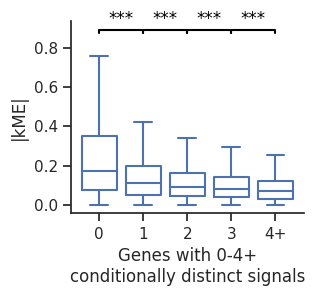

In [27]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

dfplot = kme['eQTL']
x='num'
y='|kME|'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel(f'Genes with 0-4+\nconditionally distinct signals')
plt.xticks([0,1,2,3,4], [0,1,2,3,'4+'])

y_max = ax.get_ylim()[1] * 1.1
pairs=[(0,1), (1, 2), (2, 3), (3, 4)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0],y], dfplot.loc[dfplot[x]==pair[1],y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Genes_with_0-4_KME.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

## phastcons

In [29]:
df_phastcons = pd.read_csv("/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/phastcons/chrAuto.phastcons.gene.cov0.5.txt", sep="\t", header=None, usecols=[3,4], names=['phenotype_id', 'PhastCons'])

In [30]:
pahstcons = dict()
for qtl in qtls:
    pahstcons[qtl] = pd.merge(perm[qtl], df_phastcons, on="phenotype_id")
    pahstcons[qtl] = pd.merge(pahstcons[qtl], signal[qtl], on=["tissue", "phenotype_id"], how='left')
    pahstcons[qtl]['num'] = pahstcons[qtl]['num'].fillna(0)
    pahstcons[qtl] = pahstcons[qtl].dropna(subset=['PhastCons'])

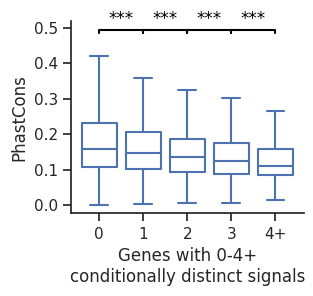

In [31]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

dfplot = pahstcons['eQTL']
x='num'
y='PhastCons'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel('Genes with 0-4+\nconditionally distinct signals')
plt.xticks([0,1,2,3,4], [0,1,2,3,'4+'])

y_max = ax.get_ylim()[1] * 1.1
pairs=[(0,1), (1, 2), (2, 3), (3, 4)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0],y], dfplot.loc[dfplot[x]==pair[1],y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Genes_with_0-4_pha.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

# Fig. 4g-i

In [47]:
indep4 = dict()
for qtl in qtls:
    indep4[qtl] = indep[qtl][indep[qtl]['num']>=4]
    indep4[qtl]['Z'] = indep4[qtl]['slope'] / indep4[qtl]['slope_se']
    indep4[qtl]['|Z|'] = indep4[qtl]['Z'].abs()
    indep4[qtl]['MAF'] = indep4[qtl]['af'].apply(lambda x: 1 - x if x > 0.5 else x)
    indep4[qtl]['Distance to TSS (kb)'] = abs(indep4[qtl]['start_distance'])/1000

/tmp/ipykernel_564328/1337029415.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indep4[qtl]['Z'] = indep4[qtl]['slope'] / indep4[qtl]['slope_se']
/tmp/ipykernel_564328/1337029415.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indep4[qtl]['|Z|'] = indep4[qtl]['Z'].abs()
/tmp/ipykernel_564328/1337029415.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

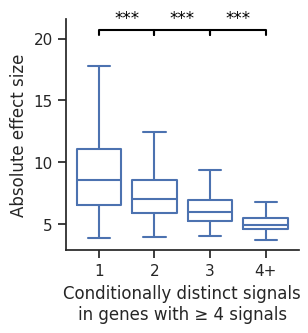

In [48]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 3))

dfplot = indep4['eQTL']
x='signal'
y='|Z|'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel('Conditionally distinct signals\nin genes with ≥ 4 signals')
plt.ylabel('Normalized |effect size|')
plt.xticks([0,1,2,3], [1,2,3,'4+'])

y_max = ax.get_ylim()[1] * 1.1
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0]+1,y], dfplot.loc[dfplot[x]==pair[1]+1,y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Genes_with_0-4_eff.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

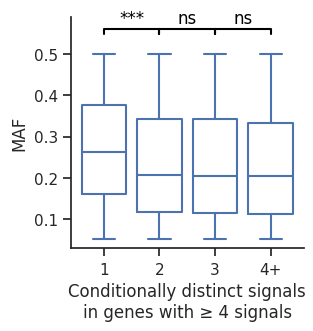

In [49]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 3))

dfplot = indep4['eQTL']
x='signal'
y='MAF'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel('Conditionally distinct signals\nin genes with ≥ 4 signals')
plt.xticks([0,1,2,3], [1,2,3,'4+'])
ax.set_ylim(ax.get_ylim()[0], 0.59)
y_max = 0.5 * 1.1
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0]+1,y], dfplot.loc[dfplot[x]==pair[1]+1,y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'
    annot, = ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    annot.set_clip_on(False)
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Genes_with_0-4_MAF.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

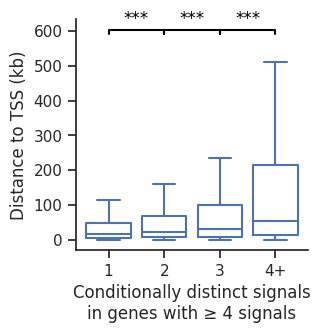

In [50]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 3))

dfplot = indep4['eQTL']
x='signal'
y='Distance to TSS (kb)'

ax = sns.boxplot(data=dfplot, y=y, x=x, fill=False, showfliers=False)
plt.xlabel('Conditionally distinct signals\nin genes with ≥ 4 signals')
plt.xticks([0,1,2,3], [1,2,3,'4+'])

y_max = ax.get_ylim()[1] * 1.1
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(dfplot.loc[dfplot[x]==pair[0]+1,y], dfplot.loc[dfplot[x]==pair[1]+1,y], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Genes_with_0-4_TSS.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

# Fig. 4j

In [95]:
label_mapping = {'intergenic_region':'intergenic','upstream_gene':'upstream','downstream_gene':'downstream','5_prime_UTR':"5' UTR",'3_prime_UTR':"3' UTR",
                 '5_prime_UTR_premature_start_codon_gain':"5' UTR premature\nstart codon gain",'non_coding_transcript_exon':'non-coding\ntranscript exon',
                 'splice_region':'splice region','splice_acceptor':'splice acceptor','splice_donor':'splice donor','start_lost':'start lost','stop_lost':'stop lost',
                 'stop_gained':'stop gained','stop_retained':'stop retained','initiator_codon':'initiator codon',
                 "E1":"TssA", "E2":"TssAHet", "E3":"TxFlnk", "E4":"TxFlnkWk", "E5":"TxFlnkHet", "E6":"EnhA", "E7":"EnhAMe", "E8":"EnhAWk",
                 "E9":"EnhAHet", "E10":"EnhPois", "E11":"ATAC_Is", "E12":"TssBiv", "E13":"Repr", "E14":"ReprWk", "E15":"Qui"}

path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/functional_enrichment"

# focal SNPs
df1 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/rank/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/rank/OR_results.csv')
        df_['Tissue'] = tis
        df1 = pd.concat([df1, df_])
df1['QTL'] = df1['QTL'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('_variant', '', regex=False)
df1['log2(odds ratio)'] = np.log2(df1['Odds ratio'])
df1 = df1.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df1['Source'] = 'molQTL'

# control SNPs
df2 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/rank/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/rank/OR_control_results.csv')
        df_['Tissue'] = tis
        df2 = pd.concat([df2, df_])
df2['QTL'] = df2['QTL'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('_variant', '', regex=False)
df2['log2(odds ratio)'] = np.log2(df2['Odds ratio'])
df2 = df2.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df2['Source'] = 'Control'

# merge
df_enrich = pd.concat([df1, df2], ignore_index=True)
df_ontology = df_enrich[~df_enrich['Annotation'].str.startswith('E')].reset_index(drop=True)
df_state = df_enrich[df_enrich['Annotation'].str.startswith('E')].reset_index(drop=True)
df_enrich['Annotation'] = df_enrich['Annotation'].replace(label_mapping)
df_ontology['Annotation'] = df_ontology['Annotation'].replace(label_mapping)
df_state['Annotation'] = df_state['Annotation'].replace(label_mapping)
df_enrich

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissue,log2(odds ratio),Source
0,4,intergenic,0.796613,0.679487,0.933929,4.699151e-03,907,Muscle,-0.328049,molQTL
1,4,downstream,1.650887,1.408142,1.935479,3.591681e-09,907,Muscle,0.723241,molQTL
2,4,5' UTR premature\nstart codon gain,1.643528,0.528938,5.106803,4.372368e-01,907,Muscle,0.716796,molQTL
3,4,EnhAHet,0.806825,0.691808,0.940964,5.863698e-03,907,Muscle,-0.309672,molQTL
4,4,upstream,1.896273,1.618405,2.221849,1.132880e-13,907,Muscle,0.923167,molQTL
...,...,...,...,...,...,...,...,...,...,...
8758,1,3' UTR,0.857669,0.585371,1.256630,5.248579e-01,1100,Oviduct,-0.221508,Control
8759,1,intragenic,2.701524,1.529067,4.772997,2.241440e-03,1100,Oviduct,1.433774,Control
8760,1,TxFlnkWk,0.915507,0.770285,1.088107,3.475224e-01,1100,Oviduct,-0.127357,Control
8761,1,TxFlnk,0.807744,0.676844,0.963960,1.719461e-02,1100,Oviduct,-0.308030,Control


/tmp/ipykernel_674618/4107072682.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_674618/4107072682.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


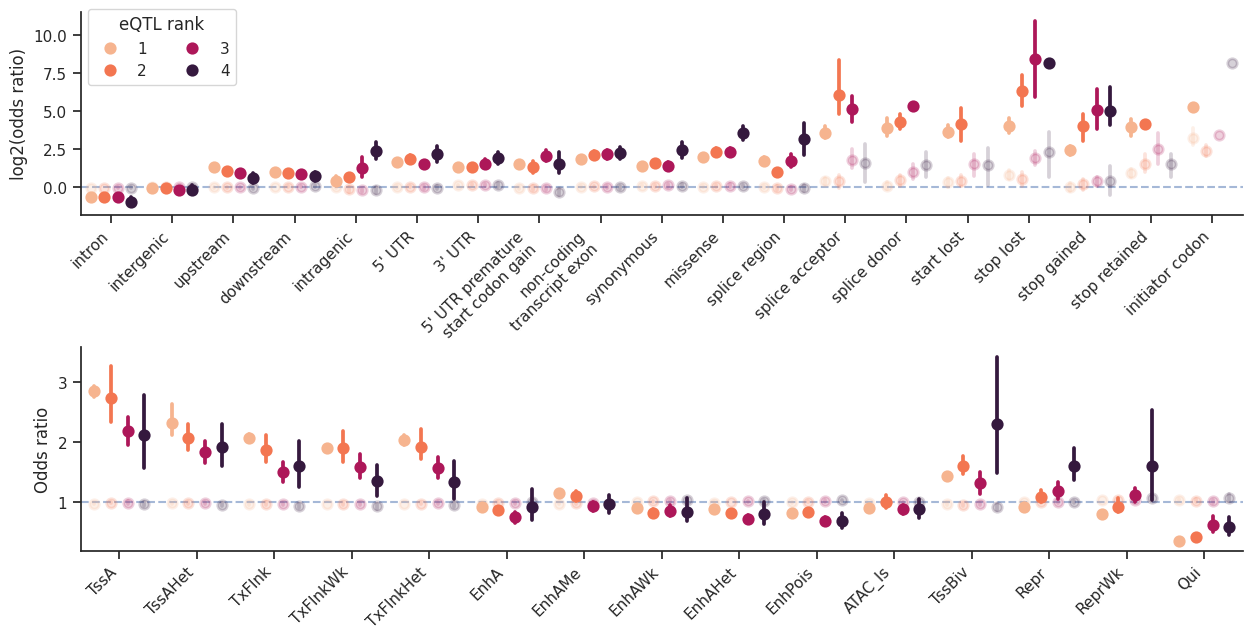

In [115]:
color_dict1 = {'1': '#F6B48F', '2': '#F37651', '3': '#AD1759', '4': '#35193E'}
x_order1=['intron', 'intergenic', 'upstream', 'downstream', 'intragenic', "5' UTR","3' UTR", "5' UTR premature\nstart codon gain", 'non-coding\ntranscript exon',
          'synonymous', 'missense', 'splice region', 'splice acceptor', 'splice donor', 'start lost', 'stop lost', 'stop gained', 'stop retained', 'initiator codon']
x_order2=["TssA", "TssAHet", "TxFlnk", "TxFlnkWk", "TxFlnkHet", "EnhA", "EnhAMe", "EnhAWk", "EnhAHet", "EnhPois", "ATAC_Is", "TssBiv", "Repr", "ReprWk", "Qui"]

def plot_enrichment(ax, df, x_order, y_col, baseline, color_dict, title=None, legend=True):
    ax.axhline(baseline, color="b", linestyle="--", alpha=0.5)

    # control SNPs    
    sns.pointplot(data=df[df['Source']=="Control"], x="Annotation", y=y_col, hue="QTL", 
                  hue_order=['1', '2', '3', '4'], legend=False, order=x_order,
                  palette=color_dict, markers="o", dodge=.65, alpha=.2, linestyles="none", ax=ax)
    
    # focal SNPs
    sns.pointplot(data=df[df['Source']=="molQTL"], x="Annotation", y=y_col, hue="QTL", 
                  hue_order=['1', '2', '3', '4'], legend=legend, order=x_order,
                  palette=color_dict, markers="o", dodge=.65, linestyles="none", ax=ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_title(title)

    return ax

sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 1, figsize=(15,7), sharex=False)
# ontology
plot_enrichment(ax=axes[0], df=df_ontology, x_order=x_order1, y_col="log2(odds ratio)", baseline=0, color_dict=color_dict1, title="")
# chromatin state
plot_enrichment(ax=axes[1], df=df_state, x_order=x_order2, y_col="Odds ratio", baseline=1, color_dict=color_dict1, title="", legend=False)
sns.move_legend(axes[0], "upper left", ncol=2, title="eQTL rank", bbox_to_anchor=(0,1.05))
sns.despine()
fig.subplots_adjust(hspace=0.65)
plt.savefig("pdf/eQTL_rank_enrichment.pdf", dpi='figure', format='pdf', bbox_inches='tight')